## 08_MACROECONOMIC_NEWS_PIPELINE 

Explainable AI Credit Risk Decision Platform Integrating Structured Borrower Data, NLP-Driven Text Intelligence, and Macroeconomic Indicators for Transparent Lending Decisions.

#### Reason:
Acquire, clean, aggregate and engineer macroeconomic news sentiment features from GDELT and merge them with LendingClub loans to create Matrix D.

In [44]:
# Import libraries
# ____________________________________________________________

import warnings
warnings.filterwarnings("ignore")

import os
import kagglehub
import shutil

import logging
from pathlib import Path
from datetime import datetime
from collections import defaultdict
import zipfile

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display
import requests

pd.set_option("display.max_columns", None)

pd.set_option("display.max_rows", 100)

pd.set_option("display.float_format", "{:,.4f}".format)

In [5]:
# PROJECT DIRECTORY STRUCTURE
# ____________________________________________________________


PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"

RAW_DIR = DATA_DIR / "raw"

EXTERNAL_DIR = DATA_DIR / "external"

GDELT_DIR = EXTERNAL_DIR / "gdelt"

REPORT_DIR = PROJECT_ROOT / "reports"

MACRO_REPORT_DIR = REPORT_DIR / "macroeconomic"

FIGURE_DIR = MACRO_REPORT_DIR / "figures"

LOG_DIR = PROJECT_ROOT / "logs"

# CREATE PROJECT FOLDERS

directories = [GDELT_DIR,MACRO_REPORT_DIR,FIGURE_DIR,LOG_DIR]

for directory in directories:
    directory.mkdir(parents=True,exist_ok=True)

In [6]:
# LOGGING CONFIGURATION
# ____________________________________________________________

log_file = LOG_DIR / "05_macroeconomic_feature_engineering.log"

logging.basicConfig(

    level=logging.INFO,

    format="%(asctime)s | %(levelname)s | %(message)s",

    handlers=[

        logging.FileHandler(log_file),

        logging.StreamHandler()])

logger = logging.getLogger(__name__)

In [7]:
# NOTEBOOK INFORMATION
# ____________________________________________________________

logger.info("EXPLAINABLE AI CREDIT RISK DECISION PLATFORM")

logger.info("Notebook: 05_macroeconomic_feature_engineering")

logger.info(f"Execution Time: {datetime.now()}")

2026-07-12 15:53:04,048 | INFO | EXPLAINABLE AI CREDIT RISK DECISION PLATFORM
2026-07-12 15:53:04,050 | INFO | Notebook: 05_macroeconomic_feature_engineering
2026-07-12 15:53:04,051 | INFO | Execution Time: 2026-07-12 15:53:04.051111


In [8]:
# PROJECT CONFIGURATION
# ____________________________________________________________

DATE_COLUMN = "DATE"

SENTIMENT_COLUMN = "V2Tone"

OUTPUT_FILE = "monthly_sentiment.csv"

RANDOM_STATE = 42

In [9]:
# LOAD GDELT DATASET
# ____________________________________________________________

logger.info("SECTION 2 - LOADING GDELT DATA")

GDELT_FILE = GDELT_DIR / "gdelt_events.csv"

print("Dataset Location")

print(GDELT_FILE)

2026-07-12 15:53:11,503 | INFO | SECTION 2 - LOADING GDELT DATA


Dataset Location
/Users/emmanuelahadzi/data/external/gdelt/gdelt_events.csv


In [10]:
# GDELT News
# ____________________________________________________________

logger.info("SECTION 3 - GDELT NEWS EXTRACTION")

# Analysis Period
# ------------------------------------------------------------

START_YEAR = 2015
END_YEAR = 2018

print(f"Analysis Period : {START_YEAR} - {END_YEAR}")


# Finance & Macroeconomic Search Terms
# ------------------------------------------------------------

SEARCH_TERMS = [
    "bank",
    "banking",
    "credit",
    "loan",
    "mortgage",
    "consumer finance",
    "default",
    "interest rate",
    "inflation",
    "recession",
    "unemployment",
    "economy",
    "financial crisis"]

print(f"Search Terms: {len(SEARCH_TERMS)}")

2026-07-12 15:53:17,127 | INFO | ================================================================================
2026-07-12 15:53:17,128 | INFO | SECTION 3 - GDELT NEWS EXTRACTION
2026-07-12 15:53:17,129 | INFO | ================================================================================


Analysis Period : 2015 - 2018
Search Terms: 13


In [11]:
# Project trip
# ____________________________________________________________

PROJECT_ROOT = Path.cwd()

print("Project root:")

print(PROJECT_ROOT)

# Create data/raw/gdelt/gkg

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "gdelt" / "gkg"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("\nSaving GKG files to:")

print(RAW_DATA_DIR)

Project root:
/Users/emmanuelahadzi

Saving GKG files to:
/Users/emmanuelahadzi/data/raw/gdelt/gkg


In [12]:
# GDELT Data
# ____________________________________________________________

def query_gdelt(term, start_date, end_date):
    """
    Query the GDELT DOC API for a given search term and date range.
    """

    params = {
        "query": term,
        "mode": "ArtList",
        "format": OUTPUT_FORMAT,
        "maxrecords": MAX_RECORDS,
        "startdatetime": start_date,
        "enddatetime": end_date}

    response = requests.get(
        BASE_URL,
        params=params,
        timeout=REQUEST_TIMEOUT)

    response.raise_for_status()

    data = response.json()

    articles = data.get("articles", [])

    return pd.DataFrame(articles)

In [13]:
# Download GDELT data
# ____________________________________________________________

url = "http://data.gdeltproject.org/gdeltv2/masterfilelist.txt"

response = requests.get(url, timeout=60)

print(response.status_code)

print(response.text[:1000])

200
150383 297a16b493de7cf6ca809a7cc31d0b93 http://data.gdeltproject.org/gdeltv2/20150218230000.export.CSV.zip
318084 bb27f78ba45f69a17ea6ed7755e9f8ff http://data.gdeltproject.org/gdeltv2/20150218230000.mentions.CSV.zip
10768507 ea8dde0beb0ba98810a92db068c0ce99 http://data.gdeltproject.org/gdeltv2/20150218230000.gkg.csv.zip
149211 2a91041d7e72b0fc6a629e2ff867b240 http://data.gdeltproject.org/gdeltv2/20150218231500.export.CSV.zip
339037 dec3f427076b716a8112b9086c342523 http://data.gdeltproject.org/gdeltv2/20150218231500.mentions.CSV.zip
10269336 2f1a504a3c4558694ade0442e9a5ae6f http://data.gdeltproject.org/gdeltv2/20150218231500.gkg.csv.zip
149723 12268e821823aae2da90882621feda18 http://data.gdeltproject.org/gdeltv2/20150218233000.export.CSV.zip
357229 744acad14559f2781a8db67715d63872 http://data.gdeltproject.org/gdeltv2/20150218233000.mentions.CSV.zip
11279827 66b03e2efd7d51dabf916b1666910053 http://data.gdeltproject.org/gdeltv2/20150218233000.gkg.csv.zip
158842 a5298ce3c6df1a8a759c61b

In [14]:
# Save master file
# ____________________________________________________________

with open("masterfilelist.txt", "w") as f:
    f.write(response.text)

print("Master file list saved.")

Master file list saved.


In [15]:
# masterfile 
# ____________________________________________________________

with open("masterfilelist.txt") as f:lines = f.readlines()

print(len(lines))

print(lines[:5])

1176756
['150383 297a16b493de7cf6ca809a7cc31d0b93 http://data.gdeltproject.org/gdeltv2/20150218230000.export.CSV.zip\n', '318084 bb27f78ba45f69a17ea6ed7755e9f8ff http://data.gdeltproject.org/gdeltv2/20150218230000.mentions.CSV.zip\n', '10768507 ea8dde0beb0ba98810a92db068c0ce99 http://data.gdeltproject.org/gdeltv2/20150218230000.gkg.csv.zip\n', '149211 2a91041d7e72b0fc6a629e2ff867b240 http://data.gdeltproject.org/gdeltv2/20150218231500.export.CSV.zip\n', '339037 dec3f427076b716a8112b9086c342523 http://data.gdeltproject.org/gdeltv2/20150218231500.mentions.CSV.zip\n']


In [16]:
# GDELT files
# ____________________________________________________________

gkg_files = []

for line in lines:

    if ".gkg.csv.zip" not in line:
        continue

    if any(year in line for year in ["2015", "2016", "2017", "2018"]):
        gkg_files.append(line.strip())

print(f"GKG files found: {len(gkg_files)}")

print(gkg_files[:10])

GKG files found: 138200
['10768507 ea8dde0beb0ba98810a92db068c0ce99 http://data.gdeltproject.org/gdeltv2/20150218230000.gkg.csv.zip', '10269336 2f1a504a3c4558694ade0442e9a5ae6f http://data.gdeltproject.org/gdeltv2/20150218231500.gkg.csv.zip', '11279827 66b03e2efd7d51dabf916b1666910053 http://data.gdeltproject.org/gdeltv2/20150218233000.gkg.csv.zip', '11212939 cd20f295649b214dd16666ca451b9994 http://data.gdeltproject.org/gdeltv2/20150218234500.gkg.csv.zip', '9728953 8f4b26e134bd6605cce2d32e92e5d3d7 http://data.gdeltproject.org/gdeltv2/20150219000000.gkg.csv.zip', '9459370 6031464dfdcb331551d491916d400c18 http://data.gdeltproject.org/gdeltv2/20150219001500.gkg.csv.zip', '10705358 84685f907404b79e7978a06a441b9731 http://data.gdeltproject.org/gdeltv2/20150219003000.gkg.csv.zip', '9555639 b02920524f0b48c07bdab6c6d354a789 http://data.gdeltproject.org/gdeltv2/20150219004500.gkg.csv.zip', '9754826 5a84073aaf4a588319da7a53a83b56f1 http://data.gdeltproject.org/gdeltv2/20150219010000.gkg.csv.zip'

In [20]:
# Call GDELT folders stored
# ____________________________________________________

feb2015_files = []

for file in gkg_files:

    url = file.split()[-1]
    filename = url.split("/")[-1]

    if filename.startswith("201502"):
        feb2015_files.append(url)

print(f"February 2015 files: {len(feb2015_files)}")

print("\nFirst five:")

for f in feb2015_files[:5]:
    print(f)

February 2015 files: 956

First five:
http://data.gdeltproject.org/gdeltv2/20150218230000.gkg.csv.zip
http://data.gdeltproject.org/gdeltv2/20150218231500.gkg.csv.zip
http://data.gdeltproject.org/gdeltv2/20150218233000.gkg.csv.zip
http://data.gdeltproject.org/gdeltv2/20150218234500.gkg.csv.zip
http://data.gdeltproject.org/gdeltv2/20150219000000.gkg.csv.zip


In [21]:
# DOWNLOAD FIRST 5 FILES
# ____________________________________________________________

DOWNLOAD_DIR = Path("downloads/gdelt")

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

TEST_FILES = feb2015_files[:5]

print(f"Downloading {len(TEST_FILES)} files...\n")

for url in TEST_FILES:

    filename = url.split("/")[-1]

    destination = DOWNLOAD_DIR / filename

    if destination.exists():

        print(f"Already exists: {filename}")
        continue

    print(f"Downloading {filename}")

    response = requests.get(url, timeout=120)

    response.raise_for_status()

    with open(destination, "wb") as f:

        f.write(response.content)

print("\nDownload Complete")



Download Complete


In [22]:
# Open Zip_files
# ____________________________________________________


zip_files = list(DOWNLOAD_DIR.glob("*.zip"))

print(f"ZIP files: {len(zip_files)}")

for zip_file in zip_files:

    with zipfile.ZipFile(zip_file, "r") as z:

        z.extractall(DOWNLOAD_DIR)

print("Extraction Complete")

ZIP files: 5
Extraction Complete


In [23]:
# Open Downloaded CSV files
# ____________________________________________________

csv_files = sorted(DOWNLOAD_DIR.glob("*.csv"))

print(csv_files[0])

df = pd.read_csv(csv_files[0],sep="\t",
                 
                 header=None,
                 
                 low_memory=False)

print(df.shape)

df.head()

downloads/gdelt/20150218230000.gkg.csv
(3188, 27)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26
0,20150218230000-0,20150218230000,2,BBC Monitoring,as listed in Russian /BBC Monitoring/(c) BBC,"ARREST#400#political#4#Rossiya, Orenburgskaya ...","ARREST#400#political#4#Rossiya, Orenburgskaya ...",TERROR;REBELS;TAX_ETHNICITY;TAX_ETHNICITY_UKRA...,"TAX_FNCACT,2011;TAX_FNCACT,3449;TAX_FNCACT,381...","4#Budapest, Budapest, Hungary#RS#HU05#47.5#19....","4#Novorossiya, Primorskiy Kray, Russia#RS#RS59...",petro poroshenko;arkadiy dvorkovich;gen aleksa...,"Petro Poroshenko,2326;Arkadiy Dvorkovich,3483;...",gazprom,"Gazprom,666","-5.3475935828877,2.13903743315508,7.4866310160...",NaN,"wc:693,c1.1:1,c1.2:1,c12.1:43,c12.10:58,c12.11...",NaN,NaN,NaN,NaN,1332|134||prisoners are treated humanely ; the...,"Channel One,628;Channel One,755;Channel One,14...","3,channels,476;3,channels reported,824;1,corre...",NaN,NaN
1,20150218230000-1,20150218230000,2,BBC Monitoring,"Al-Sharq al-Awsat website, London/BBC Monitori...",NaN,NaN,TAX_FNCACT;TAX_FNCACT_ENVOY;TAX_ETHNICITY;TAX_...,"IDEOLOGY,6790;IDEOLOGY,10592;KILL,1960;KILL,13...",1#Qatar#SA#QA#25.5#51.25#QA;1#Syria#SA#SY#35#3...,1#Turks#SA#TU##39#35#TU#9059;1#Syrian#SA#SY##3...,al-arab kobane;emrullah isler;nasirite alawite...,"Al-Arab Kobane,4903;Emrullah Isler,77;Nasirite...",development party;united states,"Development Party,3577;Development Party,3746;...","-0.54054054054054,3.82239382239382,4.362934362...",NaN,"wc:2376,c1.2:1,c1.4:7,c12.1:163,c12.10:276,c12...",NaN,NaN,NaN,NaN,332|26||greatly complicate matters#4494|37||ma...,"Emrullah Isler,83;Arab Spring,3571;Development...","2,fronts at the political,1455;2,main strategi...",NaN,NaN
2,20150218230000-2,20150218230000,1,wjon.com,http://wjon.com/wjon-news-on-demand-wednesday-...,NaN,NaN,MANMADE_DISASTER;MANMADE_DISASTER_WITHOUT_POWE...,"MANMADE_DISASTER,91;POWER_OUTAGE,91;",NaN,NaN,NaN,NaN,NaN,NaN,"0,0,0,0,29.7029702970297,0.99009900990099,93",NaN,"wc:93,c12.1:7,c12.10:10,c12.12:5,c12.13:4,c12....",http://wac.450F.edgecastcdn.net/80450F/wjon.co...,http:/wac.450F.edgecastcdn.net/80450F/wjon.com...,NaN,https://youtube.com/channel/;https://youtube.c...,NaN,"Waite Park,125;City Food,233;Adobe Flash Playe...","500,people were without power,51;",NaN,NaN
3,20150218230000-3,20150218230000,1,wjol.com,http://www.wjol.com/common/more.php?m=15&r=3&i...,NaN,NaN,LEADER;TAX_FNCACT;TAX_FNCACT_GOVERNOR;TAX_POLI...,"TAX_FNCACT,131;TAX_POLITICAL_PARTY,664;TAX_FNC...","2#Wisconsin, United States#US#USWI#44.2563#-89...","2#Wisconsin, United States#US#USWI##44.2563#-8...",michael madigan;rahm emanuel;jesus chuy garcia,"Michael Madigan,147;Rahm Emanuel,313;Jesus Chu...",NaN,NaN,"-4.58715596330275,1.8348623853211,6.4220183486...",NaN,"wc:103,c12.1:4,c12.10:13,c12.12:7,c12.13:6,c12...",NaN,NaN,NaN,NaN,NaN,"Governor Rauner,41;Speaker Michael Madigan,158...",NaN,NaN,NaN
4,20150218230000-4,20150218230000,1,straitstimes.com,http://www.straitstimes.com:80/news/world/unit...,NaN,NaN,DRONES;TAX_WORLDMAMMALS;TAX_WORLDMAMMALS_MICE;...,"TAX_FNCACT,634;TAX_FNCACT,1248;TAX_FNCACT,907;...","1#United States#US#US#38#-97#US;3#Miami, Flori...","3#Miami, Florida, United States#US#USFL#FL086#...",omid farokhzad,"Omid Farokhzad,885",columbia university medical centre;harvard med...,"Columbia University Medical Centre,680;Harvard...","-1.80505415162455,3.6101083032491,5.4151624548...",4#2#18#0#706,"wc:255,c12.1:10,c12.10:28,c12.12:11,c12.13:7,c...",http://www.straitstimes.com/sites/straitstimes...,NaN,NaN,NaN,NaN,"United States,583;Columbia University Medical ...","5,weeks,1194;",NaN,NaN


In [25]:
# ADD GKG COLUMN NAMES
# ____________________________________________________

gkg_columns = [

    "GKGRECORDID",
    "DATE",
    "SourceCollectionIdentifier",
    "SourceCommonName",
    "DocumentIdentifier",
    "Counts",
    "V2Counts",
    "Themes",
    "V2Themes",
    "Locations",
    "V2Locations",
    "Persons",
    "V2Persons",
    "Organizations",
    "V2Organizations",
    "V2Tone",
    "Dates",
    "GCAM",
    "SharingImage",
    "RelatedImages",
    "SocialImageEmbeds",
    "SocialVideoEmbeds",
    "Quotations",
    "AllNames",
    "Amounts",
    "TranslationInfo",
    "Extras"]

df.columns = gkg_columns

df.head()

,GKGRECORDID,DATE,SourceCollectionIdentifier,SourceCommonName,DocumentIdentifier,Counts,V2Counts,Themes,V2Themes,Locations,V2Locations,Persons,V2Persons,Organizations,V2Organizations,V2Tone,Dates,GCAM,SharingImage,RelatedImages,SocialImageEmbeds,SocialVideoEmbeds,Quotations,AllNames,Amounts,TranslationInfo,Extras
0,20150218230000-0,20150218230000,2,BBC Monitoring,as listed in Russian /BBC Monitoring/(c) BBC,"ARREST#400#political#4#Rossiya, Orenburgskaya ...","ARREST#400#political#4#Rossiya, Orenburgskaya ...",TERROR;REBELS;TAX_ETHNICITY;TAX_ETHNICITY_UKRA...,"TAX_FNCACT,2011;TAX_FNCACT,3449;TAX_FNCACT,381...","4#Budapest, Budapest, Hungary#RS#HU05#47.5#19....","4#Novorossiya, Primorskiy Kray, Russia#RS#RS59...",petro poroshenko;arkadiy dvorkovich;gen aleksa...,"Petro Poroshenko,2326;Arkadiy Dvorkovich,3483;...",gazprom,"Gazprom,666","-5.3475935828877,2.13903743315508,7.4866310160...",NaN,"wc:693,c1.1:1,c1.2:1,c12.1:43,c12.10:58,c12.11...",NaN,NaN,NaN,NaN,1332|134||prisoners are treated humanely ; the...,"Channel One,628;Channel One,755;Channel One,14...","3,channels,476;3,channels reported,824;1,corre...",NaN,NaN
1,20150218230000-1,20150218230000,2,BBC Monitoring,"Al-Sharq al-Awsat website, London/BBC Monitori...",NaN,NaN,TAX_FNCACT;TAX_FNCACT_ENVOY;TAX_ETHNICITY;TAX_...,"IDEOLOGY,6790;IDEOLOGY,10592;KILL,1960;KILL,13...",1#Qatar#SA#QA#25.5#51.25#QA;1#Syria#SA#SY#35#3...,1#Turks#SA#TU##39#35#TU#9059;1#Syrian#SA#SY##3...,al-arab kobane;emrullah isler;nasirite alawite...,"Al-Arab Kobane,4903;Emrullah Isler,77;Nasirite...",development party;united states,"Development Party,3577;Development Party,3746;...","-0.54054054054054,3.82239382239382,4.362934362...",NaN,"wc:2376,c1.2:1,c1.4:7,c12.1:163,c12.10:276,c12...",NaN,NaN,NaN,NaN,332|26||greatly complicate matters#4494|37||ma...,"Emrullah Isler,83;Arab Spring,3571;Development...","2,fronts at the political,1455;2,main strategi...",NaN,NaN
2,20150218230000-2,20150218230000,1,wjon.com,http://wjon.com/wjon-news-on-demand-wednesday-...,NaN,NaN,MANMADE_DISASTER;MANMADE_DISASTER_WITHOUT_POWE...,"MANMADE_DISASTER,91;POWER_OUTAGE,91;",NaN,NaN,NaN,NaN,NaN,NaN,"0,0,0,0,29.7029702970297,0.99009900990099,93",NaN,"wc:93,c12.1:7,c12.10:10,c12.12:5,c12.13:4,c12....",http://wac.450F.edgecastcdn.net/80450F/wjon.co...,http:/wac.450F.edgecastcdn.net/80450F/wjon.com...,NaN,https://youtube.com/channel/;https://youtube.c...,NaN,"Waite Park,125;City Food,233;Adobe Flash Playe...","500,people were without power,51;",NaN,NaN
3,20150218230000-3,20150218230000,1,wjol.com,http://www.wjol.com/common/more.php?m=15&r=3&i...,NaN,NaN,LEADER;TAX_FNCACT;TAX_FNCACT_GOVERNOR;TAX_POLI...,"TAX_FNCACT,131;TAX_POLITICAL_PARTY,664;TAX_FNC...","2#Wisconsin, United States#US#USWI#44.2563#-89...","2#Wisconsin, United States#US#USWI##44.2563#-8...",michael madigan;rahm emanuel;jesus chuy garcia,"Michael Madigan,147;Rahm Emanuel,313;Jesus Chu...",NaN,NaN,"-4.58715596330275,1.8348623853211,6.4220183486...",NaN,"wc:103,c12.1:4,c12.10:13,c12.12:7,c12.13:6,c12...",NaN,NaN,NaN,NaN,NaN,"Governor Rauner,41;Speaker Michael Madigan,158...",NaN,NaN,NaN
4,20150218230000-4,20150218230000,1,straitstimes.com,http://www.straitstimes.com:80/news/world/unit...,NaN,NaN,DRONES;TAX_WORLDMAMMALS;TAX_WORLDMAMMALS_MICE;...,"TAX_FNCACT,634;TAX_FNCACT,1248;TAX_FNCACT,907;...","1#United States#US#US#38#-97#US;3#Miami, Flori...","3#Miami, Florida, United States#US#USFL#FL086#...",omid farokhzad,"Omid Farokhzad,885",columbia university medical centre;harvard med...,"Columbia University Medical Centre,680;Harvard...","-1.80505415162455,3.6101083032491,5.4151624548...",4#2#18#0#706,"wc:255,c12.1:10,c12.10:28,c12.12:11,c12.13:7,c...",http://www.straitstimes.com/sites/straitstimes...,NaN,NaN,NaN,NaN,"United States,583;Columbia University Medical ...","5,weeks,1194;",NaN,NaN


In [26]:
# KEEP PROJECT COLUMNS
# ____________________________________________________

columns = [

    "GKGRECORDID",
    "DATE",
    "DocumentIdentifier",
    "SourceCommonName",
    "V2Themes",
    "V2Tone",
    "V2Locations",
    "V2Organizations",
    "V2Persons"]

df = df[columns]

df.head()

,GKGRECORDID,DATE,DocumentIdentifier,SourceCommonName,V2Themes,V2Tone,V2Locations,V2Organizations,V2Persons
0,20150218230000-0,20150218230000,as listed in Russian /BBC Monitoring/(c) BBC,BBC Monitoring,"TAX_FNCACT,2011;TAX_FNCACT,3449;TAX_FNCACT,381...","-5.3475935828877,2.13903743315508,7.4866310160...","4#Novorossiya, Primorskiy Kray, Russia#RS#RS59...","Gazprom,666","Petro Poroshenko,2326;Arkadiy Dvorkovich,3483;..."
1,20150218230000-1,20150218230000,"Al-Sharq al-Awsat website, London/BBC Monitori...",BBC Monitoring,"IDEOLOGY,6790;IDEOLOGY,10592;KILL,1960;KILL,13...","-0.54054054054054,3.82239382239382,4.362934362...",1#Turks#SA#TU##39#35#TU#9059;1#Syrian#SA#SY##3...,"Development Party,3577;Development Party,3746;...","Al-Arab Kobane,4903;Emrullah Isler,77;Nasirite..."
2,20150218230000-2,20150218230000,http://wjon.com/wjon-news-on-demand-wednesday-...,wjon.com,"MANMADE_DISASTER,91;POWER_OUTAGE,91;","0,0,0,0,29.7029702970297,0.99009900990099,93",NaN,NaN,NaN
3,20150218230000-3,20150218230000,http://www.wjol.com/common/more.php?m=15&r=3&i...,wjol.com,"TAX_FNCACT,131;TAX_POLITICAL_PARTY,664;TAX_FNC...","-4.58715596330275,1.8348623853211,6.4220183486...","2#Wisconsin, United States#US#USWI##44.2563#-8...",NaN,"Michael Madigan,147;Rahm Emanuel,313;Jesus Chu..."
4,20150218230000-4,20150218230000,http://www.straitstimes.com:80/news/world/unit...,straitstimes.com,"TAX_FNCACT,634;TAX_FNCACT,1248;TAX_FNCACT,907;...","-1.80505415162455,3.6101083032491,5.4151624548...","3#Miami, Florida, United States#US#USFL#FL086#...","Columbia University Medical Centre,680;Harvard...","Omid Farokhzad,885"


In [27]:
# EXTRACT TONE
# ____________________________________________________

df["Tone"] = (

    df["V2Tone"]

    .fillna("0")

    .str.split(",")

    .str[0])

df["Tone"] = pd.to_numeric(

    df["Tone"],

    errors="coerce")

df["Tone"].describe()

count   3,188.0000
mean       -1.2838
std         3.6439
min       -18.7500
25%        -3.4682
50%        -0.8359
75%         1.0526
max        14.6552
Name: Tone, dtype: float64

In [28]:
# CREATE FINANCE FEATURES
# ____________________________________________________

themes = [

    "BANK",
    "LOAN",
    "CREDIT",
    "DEBT",
    "DEFAULT",
    "BANKRUPTCY",
    "MORTGAGE",
    "HOUSING",
    "INFLATION",
    "RECESSION",
    "EMPLOYMENT",
    "UNEMPLOYMENT",
    "INTEREST_RATE",
    "ECONOMY"]

df["V2Themes"] = (

    df["V2Themes"]

    .fillna("")

    .str.upper())

for theme in themes:

    df[theme] = (

        df["V2Themes"]

        .str.contains(theme)

        .astype(int))

df.head()

,GKGRECORDID,DATE,DocumentIdentifier,SourceCommonName,V2Themes,V2Tone,V2Locations,V2Organizations,V2Persons,Tone,BANK,LOAN,CREDIT,DEBT,DEFAULT,BANKRUPTCY,MORTGAGE,HOUSING,INFLATION,RECESSION,EMPLOYMENT,UNEMPLOYMENT,INTEREST_RATE,ECONOMY
0,20150218230000-0,20150218230000,as listed in Russian /BBC Monitoring/(c) BBC,BBC Monitoring,"TAX_FNCACT,2011;TAX_FNCACT,3449;TAX_FNCACT,381...","-5.3475935828877,2.13903743315508,7.4866310160...","4#Novorossiya, Primorskiy Kray, Russia#RS#RS59...","Gazprom,666","Petro Poroshenko,2326;Arkadiy Dvorkovich,3483;...",-5.3476,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,20150218230000-1,20150218230000,"Al-Sharq al-Awsat website, London/BBC Monitori...",BBC Monitoring,"IDEOLOGY,6790;IDEOLOGY,10592;KILL,1960;KILL,13...","-0.54054054054054,3.82239382239382,4.362934362...",1#Turks#SA#TU##39#35#TU#9059;1#Syrian#SA#SY##3...,"Development Party,3577;Development Party,3746;...","Al-Arab Kobane,4903;Emrullah Isler,77;Nasirite...",-0.5405,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,20150218230000-2,20150218230000,http://wjon.com/wjon-news-on-demand-wednesday-...,wjon.com,"MANMADE_DISASTER,91;POWER_OUTAGE,91;","0,0,0,0,29.7029702970297,0.99009900990099,93",NaN,NaN,NaN,0.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,20150218230000-3,20150218230000,http://www.wjol.com/common/more.php?m=15&r=3&i...,wjol.com,"TAX_FNCACT,131;TAX_POLITICAL_PARTY,664;TAX_FNC...","-4.58715596330275,1.8348623853211,6.4220183486...","2#Wisconsin, United States#US#USWI##44.2563#-8...",NaN,"Michael Madigan,147;Rahm Emanuel,313;Jesus Chu...",-4.5872,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,20150218230000-4,20150218230000,http://www.straitstimes.com:80/news/world/unit...,straitstimes.com,"TAX_FNCACT,634;TAX_FNCACT,1248;TAX_FNCACT,907;...","-1.80505415162455,3.6101083032491,5.4151624548...","3#Miami, Florida, United States#US#USFL#FL086#...","Columbia University Medical Centre,680;Harvard...","Omid Farokhzad,885",-1.8051,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [29]:
# DATE ENGINEERING
# ____________________________________________________

df["DATE"] = pd.to_datetime(

    df["DATE"].astype(str).str[:8],

    format="%Y%m%d")

df["MONTH"] = df["DATE"].dt.to_period("M")

df.head()

,GKGRECORDID,DATE,DocumentIdentifier,SourceCommonName,V2Themes,V2Tone,V2Locations,V2Organizations,V2Persons,Tone,BANK,LOAN,CREDIT,DEBT,DEFAULT,BANKRUPTCY,MORTGAGE,HOUSING,INFLATION,RECESSION,EMPLOYMENT,UNEMPLOYMENT,INTEREST_RATE,ECONOMY,MONTH
0,20150218230000-0,2015-02-18,as listed in Russian /BBC Monitoring/(c) BBC,BBC Monitoring,"TAX_FNCACT,2011;TAX_FNCACT,3449;TAX_FNCACT,381...","-5.3475935828877,2.13903743315508,7.4866310160...","4#Novorossiya, Primorskiy Kray, Russia#RS#RS59...","Gazprom,666","Petro Poroshenko,2326;Arkadiy Dvorkovich,3483;...",-5.3476,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2015-02
1,20150218230000-1,2015-02-18,"Al-Sharq al-Awsat website, London/BBC Monitori...",BBC Monitoring,"IDEOLOGY,6790;IDEOLOGY,10592;KILL,1960;KILL,13...","-0.54054054054054,3.82239382239382,4.362934362...",1#Turks#SA#TU##39#35#TU#9059;1#Syrian#SA#SY##3...,"Development Party,3577;Development Party,3746;...","Al-Arab Kobane,4903;Emrullah Isler,77;Nasirite...",-0.5405,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2015-02
2,20150218230000-2,2015-02-18,http://wjon.com/wjon-news-on-demand-wednesday-...,wjon.com,"MANMADE_DISASTER,91;POWER_OUTAGE,91;","0,0,0,0,29.7029702970297,0.99009900990099,93",NaN,NaN,NaN,0.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2015-02
3,20150218230000-3,2015-02-18,http://www.wjol.com/common/more.php?m=15&r=3&i...,wjol.com,"TAX_FNCACT,131;TAX_POLITICAL_PARTY,664;TAX_FNC...","-4.58715596330275,1.8348623853211,6.4220183486...","2#Wisconsin, United States#US#USWI##44.2563#-8...",NaN,"Michael Madigan,147;Rahm Emanuel,313;Jesus Chu...",-4.5872,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2015-02
4,20150218230000-4,2015-02-18,http://www.straitstimes.com:80/news/world/unit...,straitstimes.com,"TAX_FNCACT,634;TAX_FNCACT,1248;TAX_FNCACT,907;...","-1.80505415162455,3.6101083032491,5.4151624548...","3#Miami, Florida, United States#US#USFL#FL086#...","Columbia University Medical Centre,680;Harvard...","Omid Farokhzad,885",-1.8051,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2015-02


In [30]:
 # BUILD MONTHLY FEATURES
# ____________________________________________________

monthly = (df.groupby("MONTH").agg(

        Articles=("GKGRECORDID","count"),

        AvgTone=("Tone","mean"),

        Bank=("BANK","sum"),

        Loan=("LOAN","sum"),

        Credit=("CREDIT","sum"),

        Housing=("HOUSING","sum"),

        Inflation=("INFLATION","sum"),

        Recession=("RECESSION","sum"),

        Employment=("EMPLOYMENT","sum"),

        Economy=("ECONOMY","sum")))

monthly

,Articles,AvgTone,Bank,Loan,Credit,Housing,Inflation,Recession,Employment,Economy
MONTH,,,,,,,,,,
2015-02,3188,-1.2838,63,0,18,51,33,0,31,0


#### Automated GDELT ETL Pipeline

In [45]:
# PRODUCTION GDELT ZIP ETL PIPELINE
# ____________________________________________________

# GDELT SCHEMA

GKG_COLUMNS = [

    "GKGRECORDID",
    "DATE",
    "SourceCollectionIdentifier",
    "SourceCommonName",
    "DocumentIdentifier",
    "Counts",
    "V2Counts",
    "Themes",
    "V2Themes",
    "Locations",
    "V2Locations",
    "Persons",
    "V2Persons",
    "Organizations",
    "V2Organizations",
    "V2Tone",
    "Dates",
    "GCAM",
    "SharingImage",
    "RelatedImages",
    "SocialImageEmbeds",
    "SocialVideoEmbeds",
    "Quotations",
    "AllNames",
    "Amounts",
    "TranslationInfo",
    "Extras"]

# PROJECT THEMES

THEMES = [

    "BANK",
    "BANKRUPTCY",
    "LOAN",
    "CREDIT",
    "DEBT",
    "DEFAULT",
    "MORTGAGE",
    "HOUSING",
    "EMPLOYMENT",
    "UNEMPLOYMENT",
    "INFLATION",
    "RECESSION",
    "INTEREST_RATE",
    "FEDERAL_RESERVE",
    "ECONOMY"]

# MONTHLY ACCUMULATOR

monthly_stats = defaultdict(lambda: {

    "Articles":0,
    "Tone_Sum":0.0,
    "Tone_Count":0,

    **{theme:0 for theme in THEMES}})

# PROCESS ONE ZIP FILE

def process_zip(zip_path):

    with zipfile.ZipFile(zip_path) as z:

        csv_name = z.namelist()[0]

        with z.open(csv_name) as f:

            df = pd.read_csv(

                f,

                sep="\t",

                header=None,

                names=GKG_COLUMNS,

                low_memory=False)

    # Keep only required columns

    df = df[[
        "GKGRECORDID",
        "DATE",
        "V2Themes",
        "V2Tone"]].copy()

    # Date

    df["DATE"] = pd.to_datetime(

        df["DATE"].astype(str).str[:8],

        format="%Y%m%d",

        errors="coerce")

    df = df.dropna(subset=["DATE"])

    df["MONTH"] = df["DATE"].dt.to_period("M")

    # Tone
   
    df["Tone"] = (

        df["V2Tone"]

        .fillna("0")

        .astype(str)

        .str.split(",")

        .str[0])

    df["Tone"] = pd.to_numeric(

        df["Tone"],

        errors="coerce")

   
    # Themes

    df["V2Themes"] = (

        df["V2Themes"]

        .fillna("")

        .str.upper())

    for theme in THEMES:

        df[theme] = (

            df["V2Themes"]

            .str.contains(theme, regex=False)

            .astype(int))

    # Update accumulator

    for month, group in df.groupby("MONTH"):

        stats = monthly_stats[month]

        stats["Articles"] += len(group)

        stats["Tone_Sum"] += group["Tone"].sum(skipna=True)

        stats["Tone_Count"] += group["Tone"].count()

        for theme in THEMES:

            stats[theme] += int(group[theme].sum())


In [46]:
# DOWNLOAD / PROCESS / DELETE
# ____________________________________________________

DOWNLOAD_DIR = GDELT_DIR / "temp"

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

# Example:
# feb2015_files = [...]

for i, url in enumerate(feb2015_files, start=1):

    filename = url.split("/")[-1]

    zip_path = DOWNLOAD_DIR / filename

    try:

        print(f"[{i}/{len(feb2015_files)}] {filename}")

        # Download
        # -------------------------

        r = requests.get(url, timeout=120)

        r.raise_for_status()

        with open(zip_path, "wb") as f:

            f.write(r.content)

        # Process
        # -------------------------

        process_zip(zip_path)

        # Delete ZIP
        # -------------------------

        os.remove(zip_path)

    except Exception as e:

        print(e)

print("\nFinished")

[1/956] 20150218230000.gkg.csv.zip
[2/956] 20150218231500.gkg.csv.zip
[3/956] 20150218233000.gkg.csv.zip
[4/956] 20150218234500.gkg.csv.zip
[5/956] 20150219000000.gkg.csv.zip
[6/956] 20150219001500.gkg.csv.zip
[7/956] 20150219003000.gkg.csv.zip
[8/956] 20150219004500.gkg.csv.zip
[9/956] 20150219010000.gkg.csv.zip
[10/956] 20150219011500.gkg.csv.zip
[11/956] 20150219013000.gkg.csv.zip
[12/956] 20150219014500.gkg.csv.zip
[13/956] 20150219020000.gkg.csv.zip
[14/956] 20150219021500.gkg.csv.zip
[15/956] 20150219023000.gkg.csv.zip
[16/956] 20150219024500.gkg.csv.zip
[17/956] 20150219030000.gkg.csv.zip
[18/956] 20150219031500.gkg.csv.zip
[19/956] 20150219033000.gkg.csv.zip
[20/956] 20150219040000.gkg.csv.zip
[21/956] 20150219034500.gkg.csv.zip
[22/956] 20150219041500.gkg.csv.zip
[23/956] 20150219043000.gkg.csv.zip
[24/956] 20150219044500.gkg.csv.zip
[25/956] 20150219050000.gkg.csv.zip
[26/956] 20150219051500.gkg.csv.zip
[27/956] 20150219053000.gkg.csv.zip
[28/956] 20150219054500.gkg.csv.zip
[

In [61]:
# BUILD DATASET
# ____________________________________________________

rows = []

for month, stats in monthly_stats.items():

    row = {"MONTH": str(month)}

    row.update(stats)

    rows.append(row)

macro_news = pd.DataFrame(rows)

macro_news["Average_Tone"] = (
    macro_news["Tone_Sum"] /
    macro_news["Tone_Count"])

macro_news.drop(
    columns=["Tone_Sum", "Tone_Count"],
    inplace=True)

macro_news = macro_news.sort_values("MONTH").reset_index(drop=True)

print(macro_news.shape)

macro_news.head()

(47, 18)


,MONTH,Articles,BANK,BANKRUPTCY,LOAN,CREDIT,DEBT,DEFAULT,MORTGAGE,HOUSING,EMPLOYMENT,UNEMPLOYMENT,INFLATION,RECESSION,INTEREST_RATE,FEDERAL_RESERVE,ECONOMY,Average_Tone
0,2015-02,2260527,52576,26226,97,6306,51625,0,10,31548,29818,29665,25569,0,31258,0,381,-1.2176
1,2015-03,71368,3211,518,8,528,3056,0,4,2411,3479,1054,1167,0,1425,0,25,-1.1291
2,2015-04,67180,2605,436,7,556,2453,0,0,2114,3090,843,742,0,1053,0,23,-1.1991
3,2015-05,68502,2505,566,1,623,2683,0,0,2202,3215,992,811,0,996,0,29,-1.1434
4,2015-06,68922,3055,1097,10,777,2992,0,1,2106,3047,873,675,0,843,0,29,-1.2900


In [48]:
# SAVE
# ____________________________________________________

OUTPUT_FILE = GDELT_DIR / "macro_news_index.csv"

macro_news.to_csv(OUTPUT_FILE,index=False)

print("="*60)

print("GDELT PIPELINE COMPLETE")

print("="*60)

print(f"Months Processed : {len(macro_news)}")

print(f"Saved to: {OUTPUT_FILE}")

GDELT PIPELINE COMPLETE
Months Processed : 1
Saved to: /Users/emmanuelahadzi/data/external/gdelt/macro_news_index.csv


In [49]:
# BUILD OPTIMIZED DAILY URL LIST
# ____________________________________________________

START_DATE = datetime(2015, 3, 1)

END_DATE   = datetime(2018, 12, 31)

# Group URLs by date
daily_files = defaultdict(list)

for record in gkg_files:

    url = record.split()[-1]
    filename = url.split("/")[-1]

    try:
        file_date = datetime.strptime(filename[:8], "%Y%m%d")

        if START_DATE <= file_date <= END_DATE:

            daily_files[file_date.strftime("%Y%m%d")].append(url)

    except Exception:
        continue

# Pick ONE file per day
# Prefer 11:00 UTC, otherwise use the first available file
# ------------------------------------------------------------

gdelt_urls = []

for day in sorted(daily_files.keys()):

    urls = sorted(daily_files[day])

    selected = None

    # Prefer noon snapshot
    for url in urls:
        if "120000.gkg.csv.zip" in url:
            selected = url
            break

    # Otherwise first available
    if selected is None:
        selected = urls[-1]

    gdelt_urls.append(selected)

print("OPTIMIZED GDELT DOWNLOAD LIST")
print("="*60)

print(f"Days to process : {len(gdelt_urls):,}")

print("\nFirst five:")

for u in gdelt_urls[:5]:print(u)

print("\nLast five:")

for u in gdelt_urls[-5:]:print(u)

OPTIMIZED GDELT DOWNLOAD LIST
Days to process : 1,402

First five:
http://data.gdeltproject.org/gdeltv2/20150301120000.gkg.csv.zip
http://data.gdeltproject.org/gdeltv2/20150302120000.gkg.csv.zip
http://data.gdeltproject.org/gdeltv2/20150303120000.gkg.csv.zip
http://data.gdeltproject.org/gdeltv2/20150304120000.gkg.csv.zip
http://data.gdeltproject.org/gdeltv2/20150305120000.gkg.csv.zip

Last five:
http://data.gdeltproject.org/gdeltv2/20181227120000.gkg.csv.zip
http://data.gdeltproject.org/gdeltv2/20181228120000.gkg.csv.zip
http://data.gdeltproject.org/gdeltv2/20181229120000.gkg.csv.zip
http://data.gdeltproject.org/gdeltv2/20181230120000.gkg.csv.zip
http://data.gdeltproject.org/gdeltv2/20181231120000.gkg.csv.zip


In [50]:
# SAVE OPTIMIZED URL LIST
# ____________________________________________________

url_df = pd.DataFrame({

    "Date": [u.split("/")[-1][:8] for u in gdelt_urls],

    "URL": gdelt_urls})

URL_FILE = GDELT_DIR / "gdelt_daily_urls_2015_2018.csv"

url_df.to_csv(URL_FILE, index=False)

print(f"Saved {len(url_df):,} URLs")

print(URL_FILE)

Saved 1,402 URLs
/Users/emmanuelahadzi/data/external/gdelt/gdelt_daily_urls_2015_2018.csv


In [51]:
# PROCESS DAILY SNAPSHOTS
# ____________________________________________________

DOWNLOAD_DIR = GDELT_DIR / "temp"

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

TOTAL = len(gdelt_urls)

START_FROM = 1010      # Change if resuming

for i, url in enumerate(gdelt_urls[START_FROM:], start=START_FROM + 1):

    filename = url.split("/")[-1]
    zip_path = DOWNLOAD_DIR / filename

    try:

        print(f"[{i:,}/{TOTAL:,}] {filename}")

        r = requests.get(url, timeout=120)
        r.raise_for_status()

        with open(zip_path, "wb") as f:
            f.write(r.content)

        process_zip(zip_path)

        os.remove(zip_path)

        # Save checkpoint every 100 files
        if i % 100 == 0:

            checkpoint = pd.DataFrame.from_dict(
                monthly_stats,
                orient="index")

            checkpoint.index.name = "MONTH"
            checkpoint.reset_index(inplace=True)

            checkpoint["Average_Tone"] = (
                checkpoint["Tone_Sum"] /
                checkpoint["Tone_Count"])

            checkpoint.to_csv(
                GDELT_DIR / "macro_news_checkpoint.csv",
                index=False)

            print(f"Checkpoint saved ({i:,}/{TOTAL:,})")

    except Exception as e:

        print(f"Error: {filename}")
        print(e)

print("\nPipeline Finished")

[1/1,402] 20150301120000.gkg.csv.zip
[2/1,402] 20150302120000.gkg.csv.zip
[3/1,402] 20150303120000.gkg.csv.zip
[4/1,402] 20150304120000.gkg.csv.zip
[5/1,402] 20150305120000.gkg.csv.zip
[6/1,402] 20150306120000.gkg.csv.zip
[7/1,402] 20150307120000.gkg.csv.zip
[8/1,402] 20150308120000.gkg.csv.zip
[9/1,402] 20150309120000.gkg.csv.zip
[10/1,402] 20150310120000.gkg.csv.zip
[11/1,402] 20150311120000.gkg.csv.zip
[12/1,402] 20150312120000.gkg.csv.zip
[13/1,402] 20150313120000.gkg.csv.zip
[14/1,402] 20150314120000.gkg.csv.zip
[15/1,402] 20150315120000.gkg.csv.zip
[16/1,402] 20150316120000.gkg.csv.zip
[17/1,402] 20150317120000.gkg.csv.zip
[18/1,402] 20150318120000.gkg.csv.zip
[19/1,402] 20150319120000.gkg.csv.zip
[20/1,402] 20150320120000.gkg.csv.zip
[21/1,402] 20150321120000.gkg.csv.zip
[22/1,402] 20150322120000.gkg.csv.zip
[23/1,402] 20150323120000.gkg.csv.zip
[24/1,402] 20150324120000.gkg.csv.zip
[25/1,402] 20150325120000.gkg.csv.zip
[26/1,402] 20150326120000.gkg.csv.zip
[27/1,402] 2015032712

In [62]:
# View data head
# ____________________________________________________

macro_news.head()

,MONTH,Articles,BANK,BANKRUPTCY,LOAN,CREDIT,DEBT,DEFAULT,MORTGAGE,HOUSING,EMPLOYMENT,UNEMPLOYMENT,INFLATION,RECESSION,INTEREST_RATE,FEDERAL_RESERVE,ECONOMY,Average_Tone
0,2015-02,2260527,52576,26226,97,6306,51625,0,10,31548,29818,29665,25569,0,31258,0,381,-1.2176
1,2015-03,71368,3211,518,8,528,3056,0,4,2411,3479,1054,1167,0,1425,0,25,-1.1291
2,2015-04,67180,2605,436,7,556,2453,0,0,2114,3090,843,742,0,1053,0,23,-1.1991
3,2015-05,68502,2505,566,1,623,2683,0,0,2202,3215,992,811,0,996,0,29,-1.1434
4,2015-06,68922,3055,1097,10,777,2992,0,1,2106,3047,873,675,0,843,0,29,-1.2900


In [73]:
# gdelt_features
# ____________________________________________________

OUTPUT_FILE = GDELT_DIR / "gdelt_monthly_features.csv"

macro_news.to_csv(OUTPUT_FILE,index=False)

print("Saved:", OUTPUT_FILE)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Saved: /Users/emmanuelahadzi/data/external/gdelt/gdelt_monthly_features.csv


In [66]:
# Data quality Report
# ____________________________________________________

quality = pd.DataFrame({
    
    "Column": macro_news.columns,
    
    "Data Type": macro_news.dtypes.astype(str),
    
    "Missing": macro_news.isnull().sum().values,
    
    "Missing %": (macro_news.isnull().mean() * 100).round(2),
    
    "Unique Values": [macro_news[col].nunique() for col in macro_news.columns]})

quality

,Column,Data Type,Missing,Missing %,Unique Values
MONTH,MONTH,object,0,0.0000,47
Articles,Articles,int64,0,0.0000,47
BANK,BANK,int64,0,0.0000,47
BANKRUPTCY,BANKRUPTCY,int64,0,0.0000,43
LOAN,LOAN,int64,0,0.0000,15
CREDIT,CREDIT,int64,0,0.0000,44
DEBT,DEBT,int64,0,0.0000,47
DEFAULT,DEFAULT,int64,0,0.0000,1
MORTGAGE,MORTGAGE,int64,0,0.0000,8
HOUSING,HOUSING,int64,0,0.0000,47


In [68]:
# Save For gdelt_data_quality
# ____________________________________________________

quality.to_csv(MACRO_REPORT_DIR / "gdelt_macro_data_quality.csv",index=False)

### Visual Validation

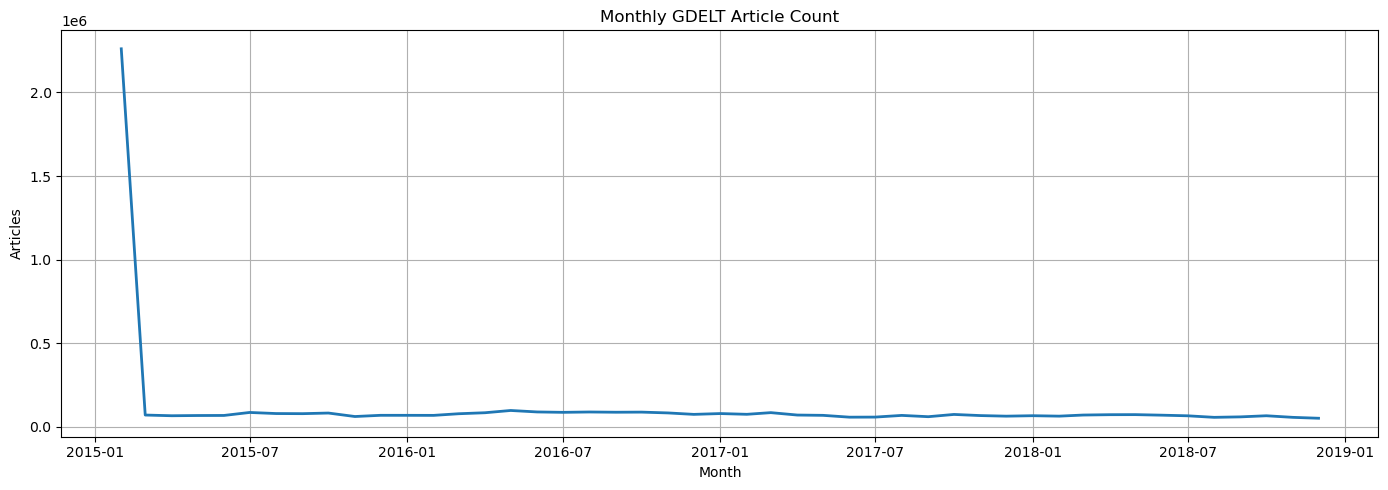

In [72]:
# Save figure
# ____________________________________________________

plt.figure(figsize=(14,5))

plt.plot(macro_news["MONTH"],macro_news["Articles"],linewidth=2)

plt.title("Monthly GDELT Article Count")
plt.xlabel("Month")
plt.ylabel("Articles")

plt.grid(True)

plt.tight_layout()

plt.show()